# In-Depth Financial Analysis of Top US Banks (2015-2024)

**Project Objective:** To conduct a comprehensive analysis of the stock performance of the five largest US banks from 2015 to 2024. This project leverages `pandas` for data wrangling and `matplotlib` & `seaborn` for advanced data visualization to uncover insights into performance, risk, and market behavior.

## 1. Environment Setup & Data Acquisition

We begin by importing the necessary libraries and fetching the stock data for JP Morgan Chase (JPM), Bank of America (BAC), Citigroup (C), Wells Fargo (WFC), and Goldman Sachs (GS). We will use the `yfinance` library for robust data retrieval.

In [18]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a professional plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [20]:
# Corrected and more robust data acquisition cell
tickers = ['JPM', 'BAC', 'C', 'WFC', 'GS']
start_date = datetime.datetime(2015, 1, 1)
end_date = datetime.datetime(2024, 1, 1)

# Use yfinance to download the data
bank_stocks = yf.download(tickers, start=start_date, end=end_date)

# For multi-level columns, it's often easier to stack the Tickers
# yfinance stacks slightly differently, so we adjust the code
df = bank_stocks.stack().reset_index()
df.rename(columns={'level_1': 'Ticker'}, inplace=True) # After stacking, the ticker column is named 'level_1'

# Ensure Date column is in datetime format (yfinance usually does this, but it's good practice)
df['Date'] = pd.to_datetime(df['Date'])

print("Data successfully loaded and reshaped using yfinance.")
df.head()

C:\Users\AJ\AppData\Local\Temp\ipykernel_11436\2218475287.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bank_stocks = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed

Data successfully loaded and reshaped using yfinance.



C:\Users\AJ\AppData\Local\Temp\ipykernel_11436\2218475287.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = bank_stocks.stack().reset_index()


Price,Date,Ticker,Close,High,Low,Open,Volume
0,2015-01-02,BAC,14.356872,14.461140,14.180419,14.429057,48951100
1,2015-01-02,C,40.653786,40.975959,40.301645,40.728711,11137800
2,2015-01-02,GS,157.990311,159.063023,156.600647,158.713583,1877700
3,2015-01-02,JPM,46.948074,47.301178,46.632531,46.715174,12600000
4,2015-01-02,WFC,40.370850,40.732488,39.994447,40.673446,11700900


In [34]:
df.groupby('Ticker')['Close'].max()

Ticker
BAC     45.085976
C       68.242950
GS     384.913879
JPM    163.672073
WFC     53.874908
Name: Close, dtype: float64

## 2. High-Level Performance Analysis

This section provides a big-picture view of how the stocks performed over the entire period.

### 2.1. Closing Price and Trading Volume
We'll plot the closing price and the corresponding trading volume to see the relationship between price trends and trading activity. Here we use Wells Fargo (WFC) as an example.

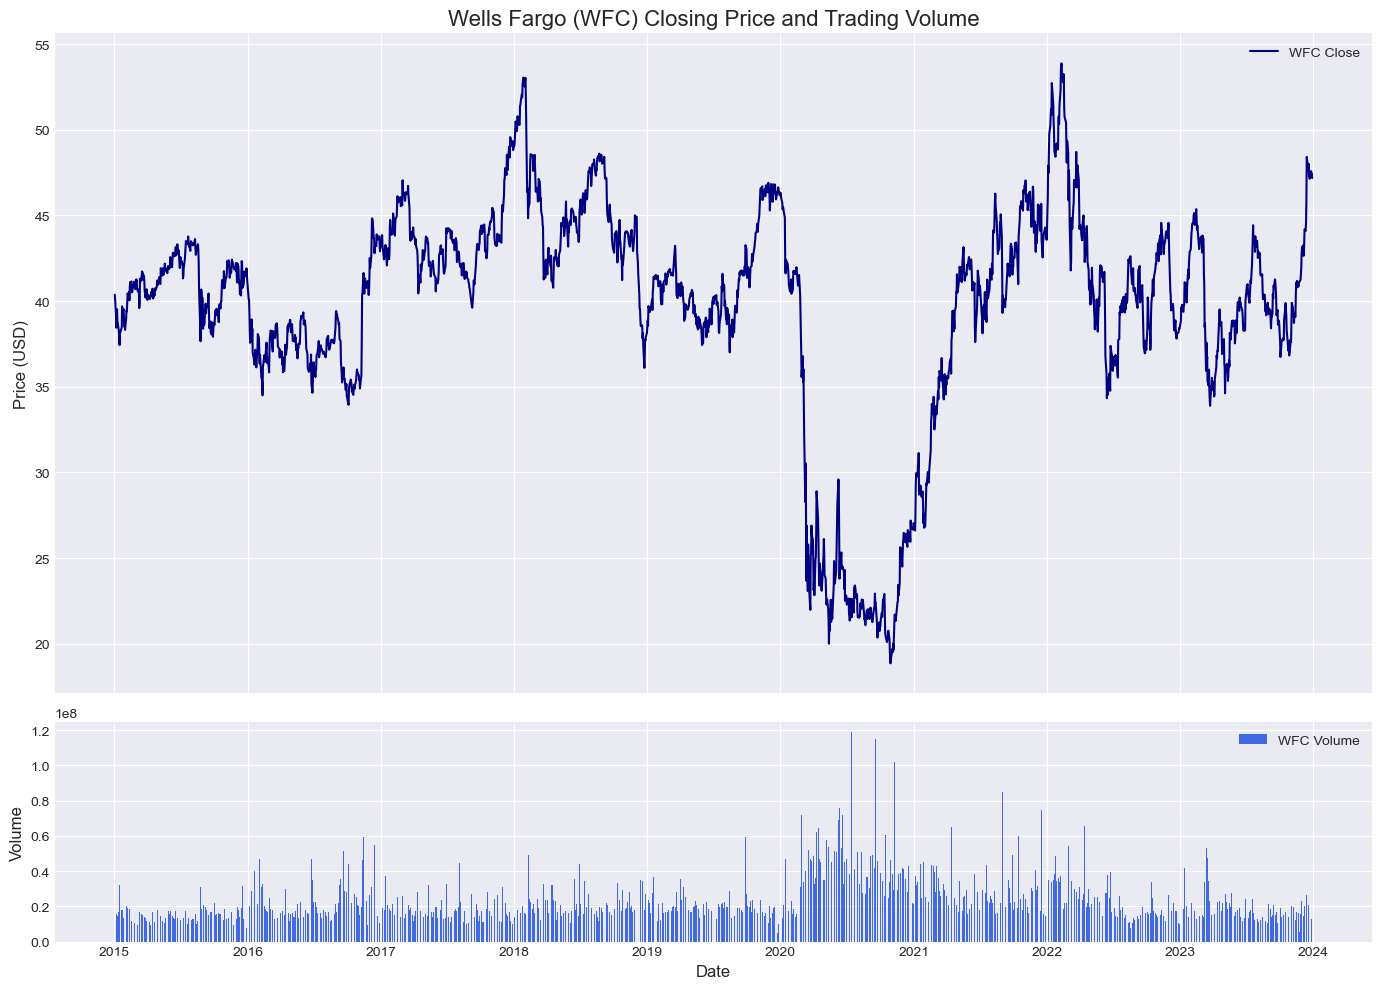

In [22]:
wfc_df = df[df['Ticker'] == 'WFC']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(wfc_df['Date'], wfc_df['Close'], label='WFC Close', color='navy')
ax1.set_title('Wells Fargo (WFC) Closing Price and Trading Volume', fontsize=16)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend()

ax2.bar(wfc_df['Date'], wfc_df['Volume'], label='WFC Volume', color='royalblue')
ax2.set_ylabel('Volume', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

### 2.2. Cumulative Returns

To compare the long-term performance, we'll calculate and plot the cumulative returns. This shows the total growth of a hypothetical $1 investment in each stock over the decade.

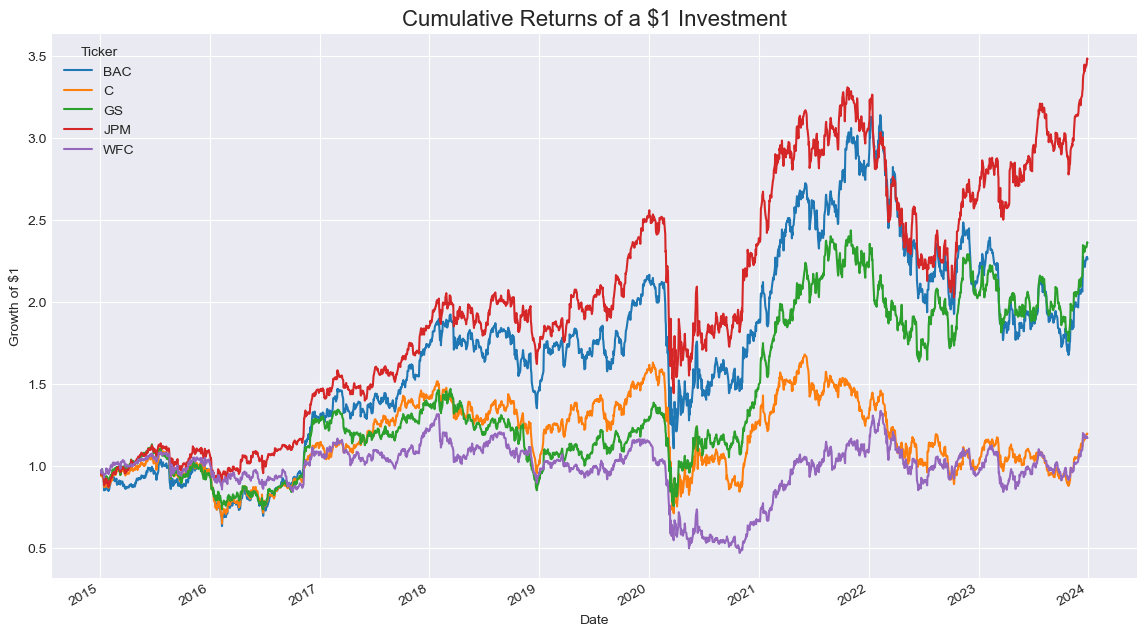

In [24]:
closing_prices = bank_stocks['Close']
daily_returns = closing_prices.pct_change().dropna()
cumulative_returns = (1 + daily_returns).cumprod()

cumulative_returns.plot(figsize=(14, 8))
plt.title('Cumulative Returns of a $1 Investment', fontsize=16)
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.legend(title='Ticker')
plt.show()

## 3. Risk, Return, and Distribution Analysis

This section focuses on quantifying the risk and return of each stock and visualizing the distribution of their daily price movements.

### 3.1. Distribution of Daily Returns
A box plot is an excellent way to compare the distribution of daily returns for all five banks. It shows the median, quartiles, and outliers for each stock, giving a clear picture of their relative volatility and return spread.

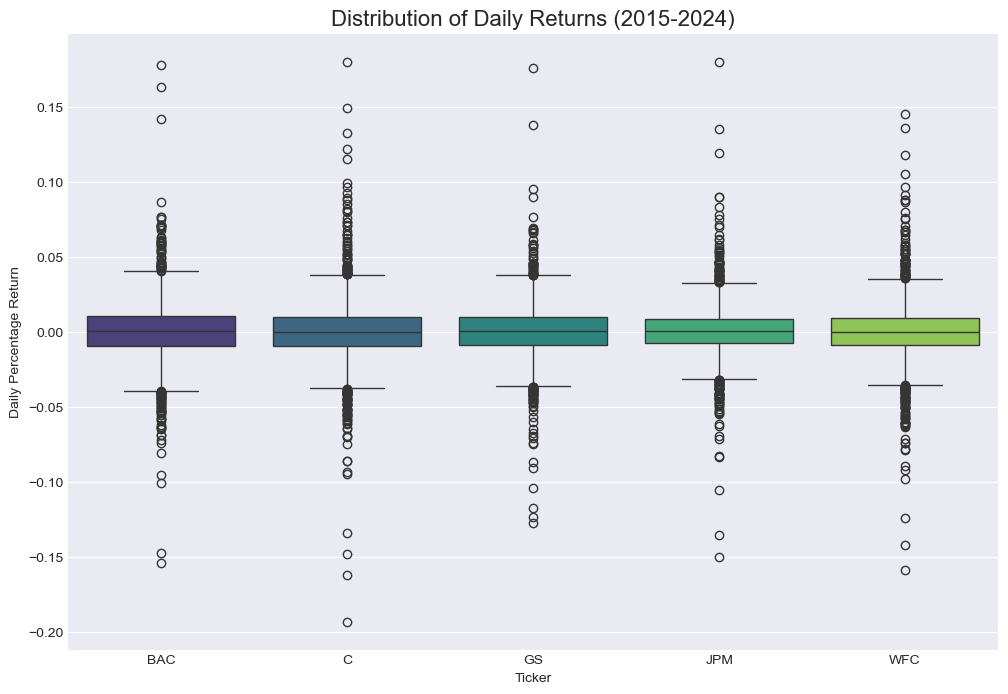

In [26]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=daily_returns, palette='viridis')
plt.title('Distribution of Daily Returns (2015-2024)', fontsize=16)
plt.ylabel('Daily Percentage Return')
plt.xlabel('Ticker')
plt.show()

### 3.2. Risk vs. Return Analysis
Here, we create a scatter plot to visualize the relationship between risk (annualized volatility) and return (annualized return). The ideal position is the top-left corner: high return with low risk.

C:\Users\AJ\AppData\Local\Temp\ipykernel_11436\3431396307.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (summary_stats['Annualized Volatility'][i], summary_stats['Annualized Return'][i]), xytext=(5,5), textcoords='offset points')


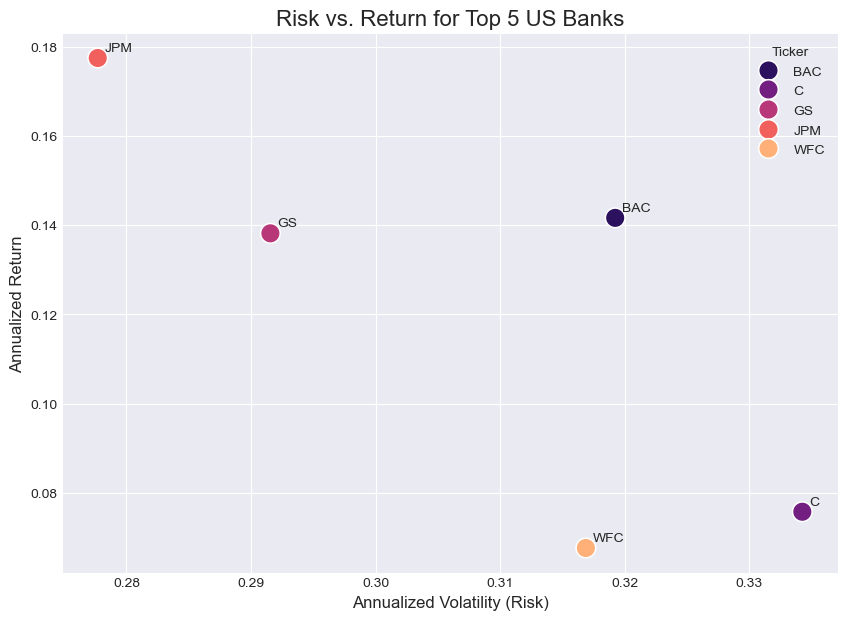

In [28]:
summary_stats = pd.DataFrame({
    'Annualized Return': daily_returns.mean() * 252,
    'Annualized Volatility': daily_returns.std() * np.sqrt(252)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annualized Volatility', y='Annualized Return', data=summary_stats, hue=summary_stats.index, s=200, palette='magma')

# Annotate points
for i, txt in enumerate(summary_stats.index):
    plt.annotate(txt, (summary_stats['Annualized Volatility'][i], summary_stats['Annualized Return'][i]), xytext=(5,5), textcoords='offset points')

plt.title('Risk vs. Return for Top 5 US Banks', fontsize=16)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend(title='Ticker')
plt.show()

## 4. Deeper Dive into Price Action & Market Behavior

This final section examines the daily price action in more detail and analyzes performance during different economic phases.

### 4.1. OHLC Chart (Open, High, Low, Close)
Instead of a simple line plot, an OHLC chart provides more detail on daily price movements. Let's create one for Goldman Sachs (GS) for the year 2023.

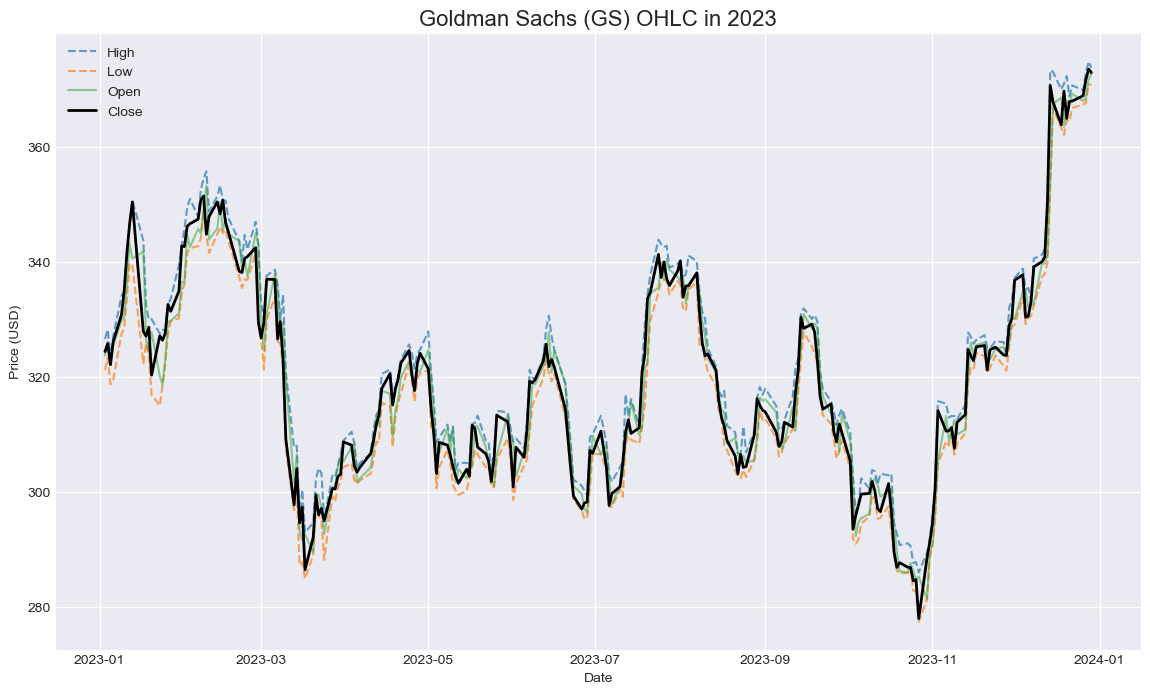

In [30]:
gs_2023 = df[(df['Ticker'] == 'GS') & (df['Date'].dt.year == 2023)]

plt.figure(figsize=(14, 8))
plt.plot(gs_2023['Date'], gs_2023['High'], label='High', alpha=0.7, linestyle='--')
plt.plot(gs_2023['Date'], gs_2023['Low'], label='Low', alpha=0.7, linestyle='--')
plt.plot(gs_2023['Date'], gs_2023['Open'], label='Open', alpha=0.5)
plt.plot(gs_2023['Date'], gs_2023['Close'], label='Close', color='black', linewidth=2)

plt.title('Goldman Sachs (GS) OHLC in 2023', fontsize=16)
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend()
plt.show()

### 4.2. Performance During Different Market Phases
How did these banks perform before, during, and after the 2020 COVID-19 crash? We'll segment the data and calculate the total return in each period.

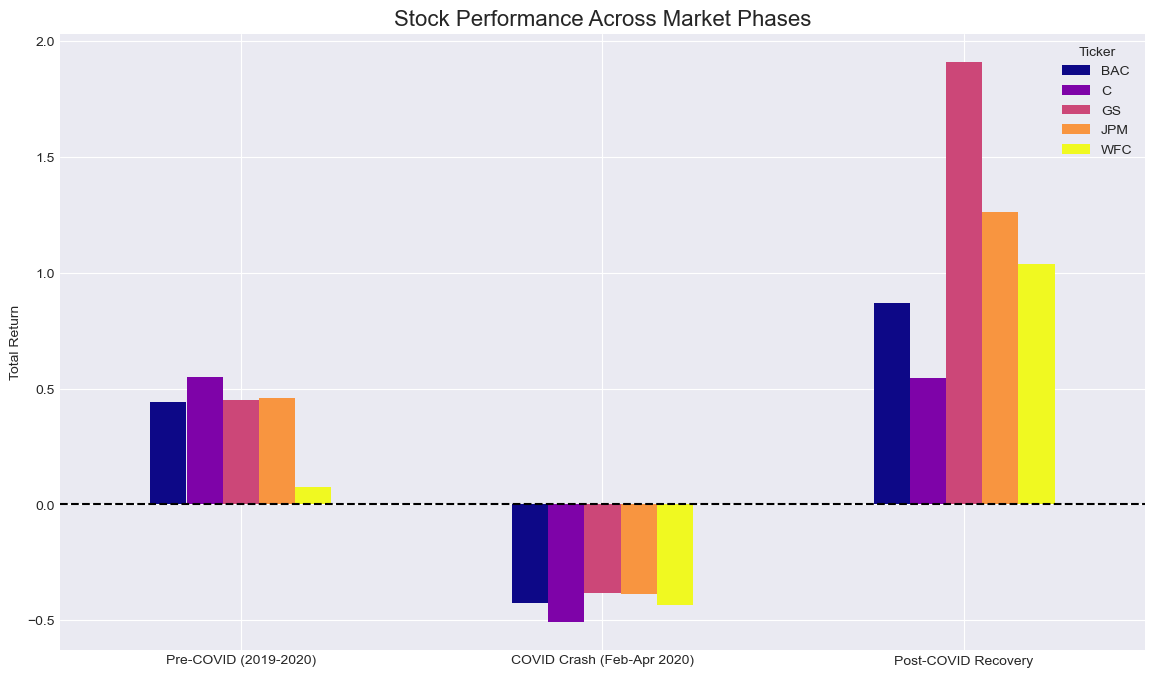

In [32]:
# Define market phases
pre_covid = daily_returns.loc['2019-01-01':'2020-02-19']
covid_crash = daily_returns.loc['2020-02-20':'2020-04-01']
post_covid = daily_returns.loc['2020-04-02':'2024-01-01']

# Calculate total return in each phase
performance_phases = pd.DataFrame({
    'Pre-COVID (2019-2020)': (1 + pre_covid).prod() - 1,
    'COVID Crash (Feb-Apr 2020)': (1 + covid_crash).prod() - 1,
    'Post-COVID Recovery': (1 + post_covid).prod() - 1
})

performance_phases.T.plot(kind='bar', figsize=(14, 8), colormap='plasma')
plt.title('Stock Performance Across Market Phases', fontsize=16)
plt.ylabel('Total Return')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linestyle='--') # Add a zero line
plt.show()

## 5. Final Conclusion

This expanded analysis reveals several key insights:

1.  **Performance Varies:** While all stocks are correlated, their long-term performance (cumulative returns) and risk-return profiles differ significantly. JPM and GS generally showed stronger risk-adjusted returns.
2.  **Systemic Risk is Evident:** The 2020 market crash impacted all banks negatively and severely, confirming that macroeconomic events are a primary driver of performance in this sector. The high correlation between stocks further supports this.
3.  **Volatility as a Key Differentiator:** The box plot visualization clearly showed that some banks (like Citigroup) have a wider distribution of daily returns, indicating higher volatility and day-to-day risk compared to others.

This project effectively demonstrates a robust workflow for financial analysis, combining data manipulation with a wide array of visualization techniques to draw meaningful and actionable conclusions.